In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def wrap_angle(a):
    return np.arctan2(np.sin(a), np.cos(a))

In [3]:
df_raw = pd.read_csv('mouse_tortuous.csv')
wind_direction = np.pi

In [4]:
# data in cm, convert to meters
df_raw.x /= 100
df_raw.y /= 100

In [5]:
scaling = 1

In [6]:
df_calibrated = df_raw*scaling

In [7]:
# estimate time stamps: data collected at 30 Hz; I digitized at half the display frequency
# so should be 15 Hz.. 
timestamps = np.arange(0, df_calibrated.shape[0]*0.066, 0.066)

In [8]:
df_calibrated['timestamps_sec'] = timestamps

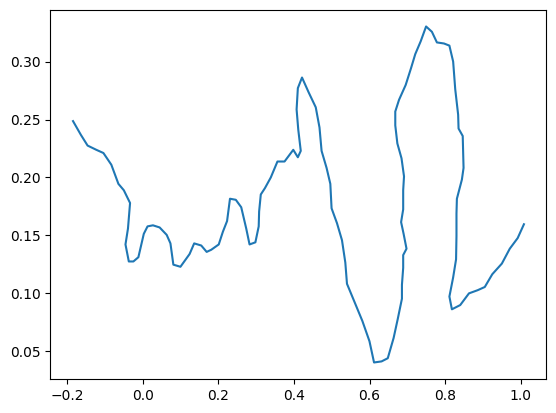

In [9]:
plt.plot(df_calibrated.x.values, df_calibrated.y.values)

In [10]:
from scipy.interpolate import UnivariateSpline

In [11]:
interp_timestamps_sec = np.arange(0, df_calibrated.timestamps_sec.max(), 0.01)

In [12]:
interp_timestamps_sec

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99, 1.  , 1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09,
       1.1 , 1.11, 1.12, 1.13, 1.14, 1.15, 1.16, 1.17, 1.18, 1.19, 1.2 ,
       1.21, 1.22, 1.23, 1.24, 1.25, 1.26, 1.27, 1.28, 1.29, 1.3 , 1.31,
       1.32, 1.33, 1.34, 1.35, 1.36, 1.37, 1.38, 1.39, 1.4 , 1.41, 1.42,
       1.43, 1.44, 1.45, 1.46, 1.47, 1.48, 1.49, 1.

In [13]:
spline_x = UnivariateSpline(df_calibrated.timestamps_sec, df_calibrated.x, s=1e-4, k=5)  # s=smoothing amount
interp_x = spline_x(interp_timestamps_sec)

spline_y = UnivariateSpline(df_calibrated.timestamps_sec, df_calibrated.y, s=1e-4, k=5)  # s=smoothing amount
interp_y = spline_y(interp_timestamps_sec)

In [14]:
df_calibrated_interp = pd.DataFrame({'timestamps_sec': interp_timestamps_sec,
                                     'x': interp_x,
                                     'y': interp_y})

1.8


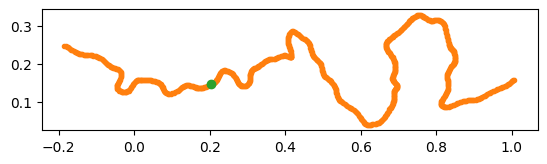

In [17]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(df_calibrated.x.values, df_calibrated.y.values)
ax.plot(df_calibrated_interp.x.values, df_calibrated_interp.y.values, '.')

tix = 180
ax.plot(df_calibrated_interp.x.values[tix], df_calibrated_interp.y.values[tix], 'o')

print(df_calibrated_interp.timestamps_sec.values[tix])

ax.set_aspect('equal')

In [18]:
import pynumdiff

In [19]:
dt = np.median(np.diff(df_calibrated_interp.timestamps_sec.values))
_, xvel = pynumdiff.savgoldiff(df_calibrated_interp.x, dt, [2, 3, 3])
_, yvel = pynumdiff.savgoldiff(df_calibrated_interp.y, dt, [2, 3, 3])

In [20]:
from braid_analysis import flymath

df_calibrated_interp['xvel'] = xvel
df_calibrated_interp['yvel'] = yvel
df_calibrated_interp['time_relative_to_flash'] = df_calibrated_interp['timestamps_sec'] - df_calibrated_interp.timestamps_sec.values[tix]
df_calibrated_interp['obj_id_unique_event'] = 'shark_a'
df_calibrated_interp['obj_id_unique'] = 'shark_a'
df_calibrated_interp = flymath.assign_course_and_ang_vel_to_dataframe(df_calibrated_interp)

df_calibrated_interp.course_smoothish -= wind_direction + np.pi
df_calibrated_interp.course_smoothish = wrap_angle(df_calibrated_interp.course_smoothish)

In [21]:
np.mean(np.sqrt(df_calibrated_interp.xvel**2 + df_calibrated_interp.yvel**2))

0.274752817302218

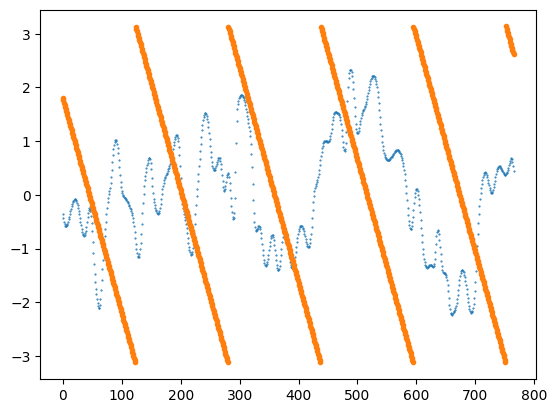

In [22]:
plt.plot(df_calibrated_interp.course_smoothish, '.', markersize=1)

ix = df_calibrated_interp.index.values
slope = -0.04
intercept=1.8
line = slope*ix + intercept

plt.plot(ix, wrap_angle(line), '.')


In [23]:
from align_course_direction_analysis import unifying_algo_analysis as uaa

In [24]:
trajec = df_calibrated_interp

In [25]:
trajec.shape

(766, 11)

In [26]:
course = trajec.course_smoothish.values
abs_min_ix = 200
abs_max_ix = 800
min_ix_range = 300
max_ix_range = 400

In [28]:
unifying_algo_fit = uaa.bootstrap_miop_affine_fit(course, 
                                                  abs_min_ix, abs_max_ix, min_ix_range, max_ix_range, 
                                                  npoints = 50, 
                                                  n_bootstraps=2, 
                                                  use_cvx_affine=True, 
                                                  include_translation=True, 
                                                  pis_max = 20, 
                                                  intercept_max = 4,
                                                  huber_M=1.0,
                                                  ignore_large_errors=True,
                                                  error_threshold=2.0,
                                                  large_error_penalty=1.0)


Interrupt request received


/home/caveman/PY38/lib/python3.8/site-packages/cvxpy/problems/problem.py:1385: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


In [29]:
# Sort 
sorted_fit = unifying_algo_fit.sort_values('rmse_affine')
best_ix = sorted_fit.index[0]
best_unifying_algo_fit = unifying_algo_fit.iloc[best_ix]

In [30]:
sorted_fit

,min_ix,max_ix,slope,intercept,rotation,major_axis,minor_axis,AM_0_0,AM_0_1,AM_1_0,AM_1_1,tx,ty,rho,mean_residuals,axis_ratio,rmse_affine,shift_ix
0,436,756,-0.018553,-1.745393,1.716904,0.999837,-0.049120,-0.026886,-0.151088,-0.151088,0.977603,0.435914,0.143809,0.948455,-0.022319,0.049128,0.573536,584
1,255,618,-0.020938,6.322015,1.872900,0.970252,0.119173,0.194514,-0.241753,-0.241753,0.894911,0.506593,0.130207,0.800540,0.025631,0.122827,0.643455,302


In [31]:
#best_unifying_algo_fit = unifying_algo_fit.iloc[0]
ix_all, course, linear_fit_angle, affine_fit_angle = uaa.build_miop_and_affine_predictions_from_model(course, best_unifying_algo_fit)

In [32]:
import figurefirst as fifi

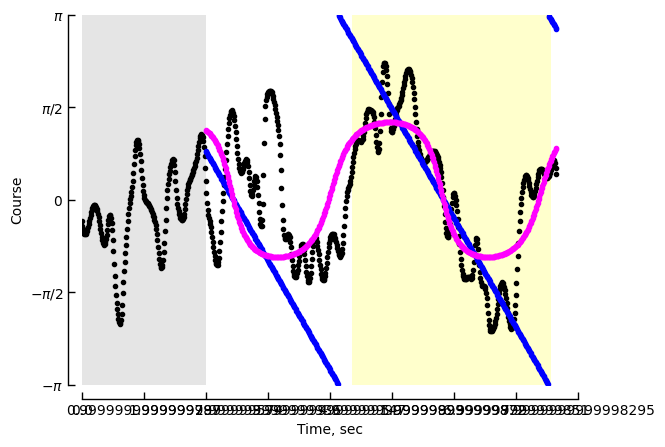

In [33]:
fig = plt.figure()
ax = fig.add_subplot(111)

# shading for before search
ax.fill_betweenx([np.pi, -np.pi], 
                 0, 
                 abs_min_ix, 
                 color='gray', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# add shading for region of interest where fit was applied
min_ix = int(best_unifying_algo_fit.min_ix)
max_ix = int(best_unifying_algo_fit.max_ix)
ax.fill_betweenx([np.pi, -np.pi], 
                 min_ix, 
                 max_ix, 
                 color='yellow', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# plot course, linear fit, and affine fit
ax.plot(ix_all, course, '.', color='black')
ax.plot(ix_all[abs_min_ix:], linear_fit_angle[abs_min_ix:], '.', color='blue')
ax.plot(ix_all[abs_min_ix:], affine_fit_angle[abs_min_ix:], '.', color='magenta')

# Add ticks, labels, etc. 
ax.set_xlim(0, ix_all[-1])
ax.set_ylim(-np.pi, np.pi)

xticks = np.arange( np.min(ix_all), np.max(ix_all) + 50, 100)
dt = np.median(np.diff(df_calibrated_interp.timestamps_sec.values))
xticklabels = dt*xticks
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_xlabel('Time, sec')

ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['$-\pi$', '$-\pi/2$','$0$','$\pi/2$','$\pi$',])
ax.set_ylabel('Course')

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'])

In [34]:
unifying_algo_fit['abs_slope'] = np.abs(unifying_algo_fit['slope'])
uaa.get_weighted_value(unifying_algo_fit, col='abs_slope')

0.019608574020469696

In [35]:
uaa.get_weighted_value(unifying_algo_fit, col='rho')

0.8829672596630036